# P4. QEC Using Dynamic Circuit

## Repetition code

This part prepares $|0\rangle$ and $|1\rangle$ and goes through the noise models under the 4 circuits described below and checks whether the logical state is preserved.

1. **Bare physical memory**: prepare → storage noise → measure
2. **Encoded, no syndrome**: encode → storage noise → decode → logical measure
3. **Error detection + postselection**: encode → storage noise → syndrome → keep only shots with an all-zero syndrome → decode → logical measure
4. **Dynamic QEC**: encode → first half of storage noise → syndrome → conditional correction → remaining storage noise → decode → logical measure

In [158]:
#SETUP
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from qiskit import ClassicalRegister, QuantumCircuit, QuantumRegister, transpile
from qiskit.circuit.classical import expr
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, ReadoutError, depolarizing_error, pauli_error

SHOTS = 20_000
CODE_DISTANCE = 11 # choose any odd n >= 3, e.g. 3, 5, 7, or 9
STORAGE_ROUNDS = 12
SEED = 1557


In [159]:
def make_noise_model(
    one_qubit_error=0.001,
    idle_error=0.001,
    two_qubit_error=0.01,
    reset_error=0.01,
    readout_error=0.01,
):
    noise_model = NoiseModel()

    error_1q = depolarizing_error(one_qubit_error, 1)
    error_idle = depolarizing_error(idle_error, 1)
    error_2q = depolarizing_error(two_qubit_error, 2)
    error_reset = pauli_error([('X', reset_error), ('I', 1 - reset_error)])
    error_readout = ReadoutError(
        [
            [1 - readout_error, readout_error],
            [readout_error, 1 - readout_error],
        ]
    )

    # Active single-qubit gate noise is independent of idle/storage noise.
    noise_model.add_all_qubit_quantum_error(
        error_1q,
        ['h', 'x', 'y', 'z', 'sdg'],
    )
    # Each id gate represents one storage round and receives idle_error.
    noise_model.add_all_qubit_quantum_error(error_idle, ['id'])
    noise_model.add_all_qubit_quantum_error(error_2q, ['cx'])
    noise_model.add_all_qubit_quantum_error(error_reset, ['reset'])
    noise_model.add_all_qubit_readout_error(error_readout)
    return noise_model


noise_model = make_noise_model()
simulator = AerSimulator(noise_model=noise_model, seed_simulator=SEED)
noise_model

<NoiseModel on ['measure', 'cx', 'sdg', 'z', 'id', 'reset', 'h', 'x', 'y']>

`idle_error` is **not X-only noise**. A one-qubit depolarizing channel introduces X, Y, and Z Pauli components. In this computational-basis memory experiment, X and Y can change the measured bit, whereas a Z error is invisible to the final Z-basis measurement. The repetition code protects only against the bit-flip component.

For an odd code distance `n`, the circuit uses `n` data qubits and one reusable ancilla. The ancilla is reset between the `n-1` sequential parity measurements, where `s[i] = q[i] xor q[i+1]`. Therefore, each encoded circuit requires only `n+1` qubits. The dynamic decoder chooses the minimum-weight error pattern consistent with the measured syndrome, so an ideal distance-`n` repetition code can correct up to `(n-1)/2` bit flips.

In [160]:
EXPERIMENTS = [
    '1. Bare physical memory',
    '2. Encoded, no syndrome',
    '3. Detection + postselection',
    '4. Dynamic QEC',
]


def validate_code_distance(n):
    if not isinstance(n, int) or isinstance(n, bool) or n < 3 or n % 2 == 0:
        raise ValueError('n must be an odd integer greater than or equal to 3')


def new_registers(n):
    validate_code_distance(n)
    data = QuantumRegister(n, 'data')
    anc = QuantumRegister(1, 'anc')
    syndrome = ClassicalRegister(n - 1, 'syn')
    logical = ClassicalRegister(1, 'logical')
    return data, anc, syndrome, logical


def add_storage(qc, qubits, rounds):
    """Represent `rounds` equal memory steps using noisy identity gates."""
    for _ in range(rounds):
        for qubit in qubits:
            qc.id(qubit)
        qc.barrier(*qubits)


def encode(qc, data):
    """Encode alpha|0> + beta|1> as alpha|0...0> + beta|1...1>."""
    for target in range(1, len(data)):
        qc.cx(data[0], data[target])


def decode(qc, data):
    """Apply the inverse of the fan-out encoding circuit."""
    for target in reversed(range(1, len(data))):
        qc.cx(data[0], data[target])


def extract_syndrome(qc, data, anc, syndrome):
    """Sequentially measure s[i] = q[i] xor q[i+1]."""
    for i in range(len(data) - 1):
        qc.reset(anc[0])
        qc.cx(data[i], anc[0])
        qc.cx(data[i + 1], anc[0])
        qc.measure(anc[0], syndrome[i])
        # Preserve the requested measure-then-next-parity ordering.
        qc.barrier(*data, *anc)


def minimum_weight_correction(n, syndrome_value):
    """Return the minimum-weight bit-error pattern matching a syndrome integer."""
    validate_code_distance(n)
    if not 0 <= syndrome_value < 2 ** (n - 1):
        raise ValueError('syndrome_value does not fit in n-1 bits')

    # Reconstruct the error chain assuming error[0] = 0.
    error = [0] * n
    for i in range(n - 1):
        syndrome_bit = (syndrome_value >> i) & 1
        error[i + 1] = error[i] ^ syndrome_bit

    # The only other pattern with the same syndrome is the bitwise complement.
    if sum(error) > n // 2:
        error = [1 - bit for bit in error]
    return tuple(i for i, bit in enumerate(error) if bit)


def _or_equal_conditions(register, values):
    """Build a balanced classical expression: register equals any value."""
    conditions = [expr.equal(register, value) for value in values]
    while len(conditions) > 1:
        next_level = []
        for i in range(0, len(conditions), 2):
            if i + 1 < len(conditions):
                next_level.append(expr.logic_or(conditions[i], conditions[i + 1]))
            else:
                next_level.append(conditions[i])
        conditions = next_level
    return conditions[0]


def apply_dynamic_correction(qc, data, syndrome):
    """Apply minimum-weight correction for every possible nonzero syndrome."""
    n = len(data)
    syndrome_values_by_qubit = {qubit: [] for qubit in range(n)}
    for syndrome_value in range(1, 2 ** (n - 1)):
        for qubit in minimum_weight_correction(n, syndrome_value):
            syndrome_values_by_qubit[qubit].append(syndrome_value)

    # One conditional X per data qubit; each condition combines its lookup entries.
    for qubit, syndrome_values in syndrome_values_by_qubit.items():
        if syndrome_values:
            condition = _or_equal_conditions(syndrome, syndrome_values)
            with qc.if_test(condition):
                qc.x(data[qubit])


def build_memory_circuit(
    experiment,
    logical_value,
    n=CODE_DISTANCE,
    storage_rounds=STORAGE_ROUNDS,
):
    validate_code_distance(n)
    if logical_value not in (0, 1):
        raise ValueError('logical_value must be 0 or 1')
    if storage_rounds < 0:
        raise ValueError('storage_rounds must be non-negative')

    data, anc, syndrome, logical = new_registers(n)
    qc = QuantumCircuit(data, anc, syndrome, logical, name=experiment)

    if logical_value == 1:
        qc.x(data[0])

    if experiment == EXPERIMENTS[0]:
        add_storage(qc, [data[0]], storage_rounds)

    elif experiment == EXPERIMENTS[1]:
        encode(qc, data)
        add_storage(qc, data, storage_rounds)
        decode(qc, data)

    elif experiment == EXPERIMENTS[2]:
        encode(qc, data)
        add_storage(qc, data, storage_rounds)
        extract_syndrome(qc, data, anc, syndrome)
        decode(qc, data)

    elif experiment == EXPERIMENTS[3]:
        encode(qc, data)
        first_half = storage_rounds // 2
        second_half = storage_rounds - first_half
        add_storage(qc, data, first_half)
        extract_syndrome(qc, data, anc, syndrome)
        apply_dynamic_correction(qc, data, syndrome)
        add_storage(qc, data, second_half)
        decode(qc, data)

    else:
        raise ValueError(f'Unknown experiment: {experiment}')

    qc.measure(data[0], logical[0])
    return qc

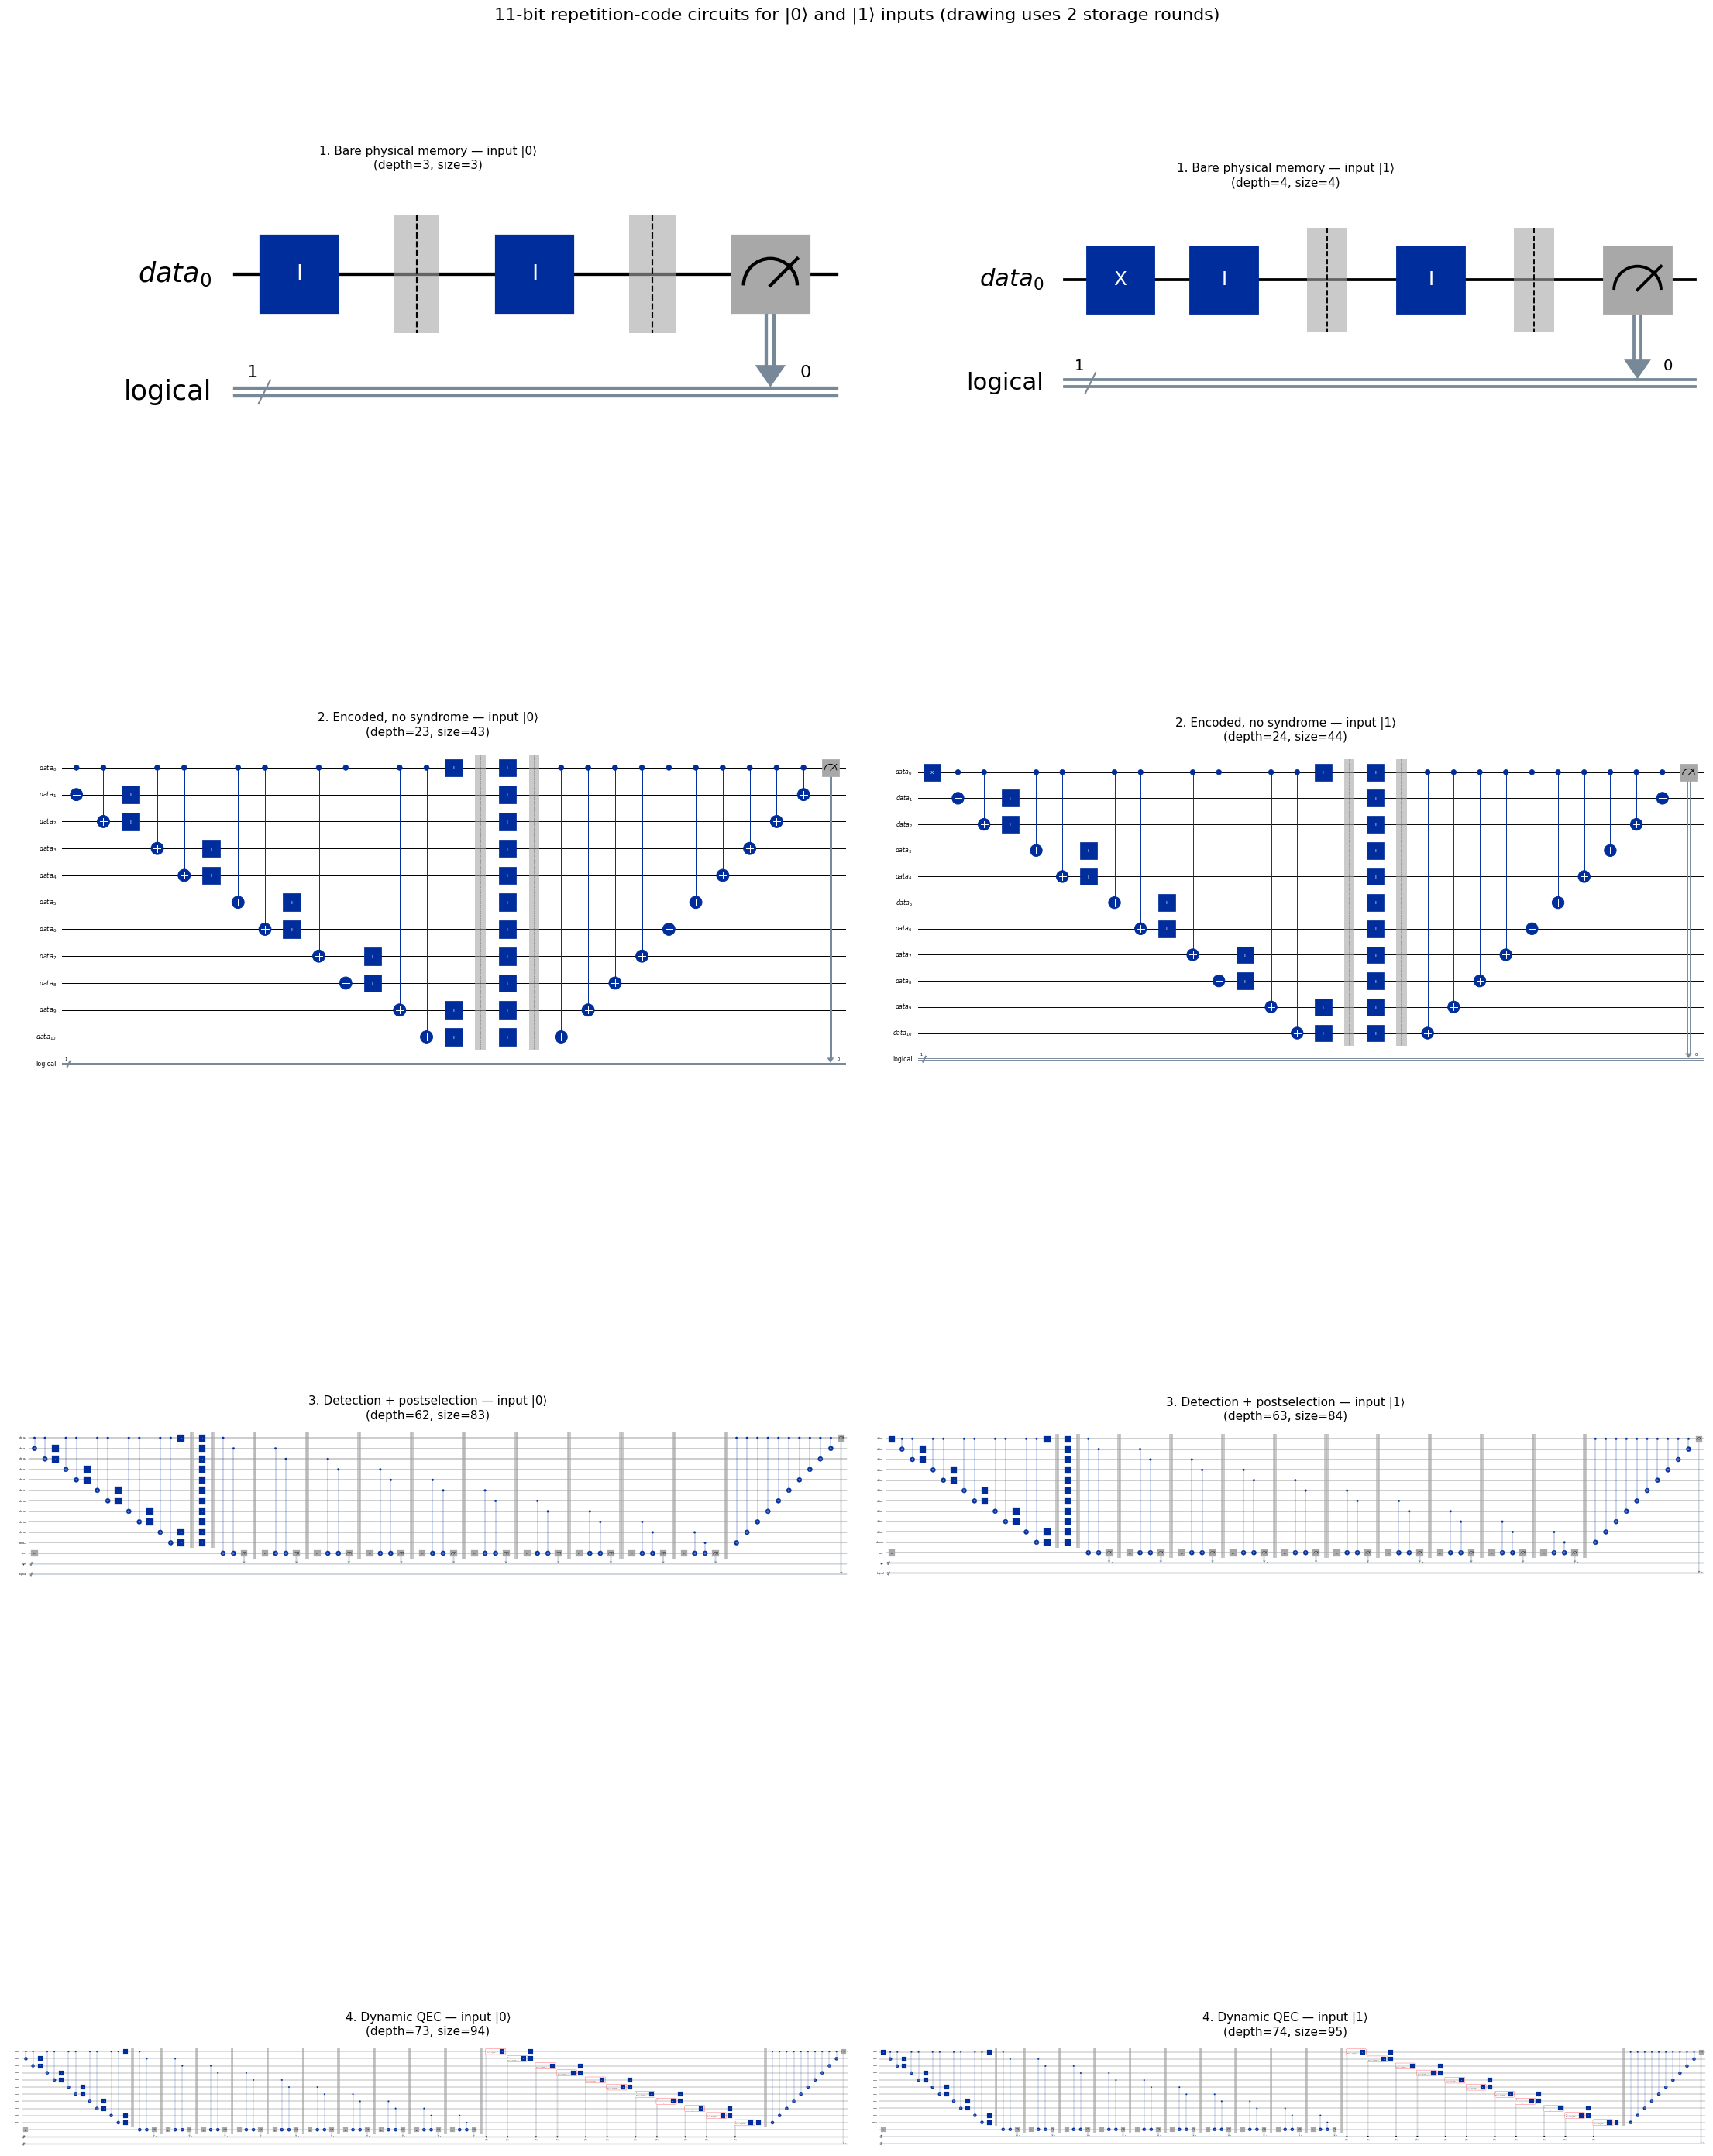

In [161]:
# Draw both logical inputs for all four methods. Fewer storage rounds keep the structure readable.
DRAW_CODE_DISTANCE = CODE_DISTANCE
DRAW_STORAGE_ROUNDS = min(STORAGE_ROUNDS, 2)
fig_height = max(21, 2.8 * DRAW_CODE_DISTANCE)
fig, axes = plt.subplots(4, 2, figsize=(22, fig_height), constrained_layout=True)

for row, experiment in enumerate(EXPERIMENTS):
    for logical_value in (0, 1):
        ax = axes[row, logical_value]
        circuit = build_memory_circuit(
            experiment,
            logical_value=logical_value,
            n=DRAW_CODE_DISTANCE,
            storage_rounds=DRAW_STORAGE_ROUNDS,
        )
        circuit.draw(
            output='mpl',
            fold=-1,
            idle_wires=False,
            scale=0.55,
            ax=ax,
            expr_len=18,
        )
        ax.set_title(
            f'{experiment} — input |{logical_value}⟩\n'
            f'(depth={circuit.depth()}, size={circuit.size()})',
            fontsize=11,
            pad=10,
        )

fig.suptitle(
    f'{DRAW_CODE_DISTANCE}-bit repetition-code circuits for |0⟩ and |1⟩ inputs '
    f'(drawing uses {DRAW_STORAGE_ROUNDS} storage rounds)',
    fontsize=16,
)
plt.show()

### Run and analyze

The experiment runs `|0⟩` and `|1⟩` with the same number of shots and combines their results. For postselection, the logical error rate uses **only accepted shots** with an all-zero syndrome as its denominator.

**Postselection cost** is the sampling loss caused by discarding rejected shots:

- `acceptance_rate = accepted_shots / total_shots`
- `discard_rate = 1 - acceptance_rate`
- `sampling_overhead = 1 / acceptance_rate`

For example, an 80% acceptance rate means that 20% of the shots are discarded and that approximately 12,500 raw shots are needed to obtain 10,000 accepted shots. The other three methods do not postselect, so their acceptance rate is 100% by definition.

In [162]:
def parse_count_key(key):
    """Return (logical_bit, syndrome_int) from Qiskit count keys."""
    # Registers were added as syn then logical, so counts are printed `logical syn`.
    pieces = key.split()
    if len(pieces) != 2:
        raise ValueError(f'Unexpected count key: {key!r}')
    return int(pieces[0], 2), int(pieces[1], 2)


def run_comparison(
    simulator=simulator,
    n=CODE_DISTANCE,
    shots=SHOTS,
    storage_rounds=STORAGE_ROUNDS,
    seed=SEED,
):
    validate_code_distance(n)
    required_qubits = n + 1  # n data qubits + one reset-and-reused parity ancilla
    capacity = getattr(getattr(simulator, 'target', None), 'num_qubits', None)
    if capacity is not None and required_qubits > capacity:
        raise ValueError(
            f'n={n} requires {required_qubits} qubits, but this simulator supports '
            f'at most {capacity}. Use n <= {capacity - 1} or a larger backend.'
        )
    if n > 9:
        warnings.warn(
            'The exact minimum-weight dynamic decoder grows exponentially with n; '
            'distances above 9 can be slow even when the qubit count fits.',
            RuntimeWarning,
            stacklevel=2,
        )
    circuits = []
    metadata = []
    for experiment in EXPERIMENTS:
        for logical_value in (0, 1):
            circuits.append(
                build_memory_circuit(
                    experiment,
                    logical_value,
                    n=n,
                    storage_rounds=storage_rounds,
                )
            )
            metadata.append((experiment, logical_value))

    compiled = transpile(
        circuits,
        simulator,
        optimization_level=0,
        seed_transpiler=seed,
    )
    result = simulator.run(compiled, shots=shots, seed_simulator=seed).result()

    totals = {
        experiment: {'accepted': 0, 'errors': 0, 'all_shots': 0}
        for experiment in EXPERIMENTS
    }
    raw_counts = {}

    for i, (experiment, expected) in enumerate(metadata):
        counts = result.get_counts(i)
        raw_counts[(experiment, expected)] = counts
        for key, count in counts.items():
            measured, syndrome = parse_count_key(key)
            totals[experiment]['all_shots'] += count

            accept = experiment != EXPERIMENTS[2] or syndrome == 0
            if accept:
                totals[experiment]['accepted'] += count
                totals[experiment]['errors'] += count * (measured != expected)

    rows = []
    for experiment in EXPERIMENTS:
        item = totals[experiment]
        accepted = item['accepted']
        logical_error_rate = item['errors'] / accepted if accepted else np.nan
        stderr = (
            np.sqrt(logical_error_rate * (1 - logical_error_rate) / accepted)
            if accepted else np.nan
        )
        acceptance_rate = accepted / item['all_shots']
        rows.append(
            {
                'experiment': experiment,
                'logical_error_rate': logical_error_rate,
                'standard_error': stderr,
                'acceptance_rate': acceptance_rate,
                'discard_rate': 1 - acceptance_rate,
                'sampling_overhead': 1 / acceptance_rate if acceptance_rate else np.inf,
                'accepted_shots': accepted,
                'total_shots': item['all_shots'],
            }
        )

    table = pd.DataFrame(rows).set_index('experiment')
    return table, raw_counts, compiled


comparison, raw_counts, compiled_circuits = run_comparison()
comparison.style.format(
    {
        'logical_error_rate': '{:.4%}',
        'standard_error': '{:.4%}',
        'acceptance_rate': '{:.2%}',
        'discard_rate': '{:.2%}',
        'sampling_overhead': '{:.3f}×',
        'accepted_shots': '{:,.0f}',
        'total_shots': '{:,.0f}',
    }
)

/var/folders/ns/srwmbl_53fq2h0mc9v695mhr0000gn/T/ipykernel_93410/3370287986.py:99: RuntimeWarning: The exact minimum-weight dynamic decoder grows exponentially with n; distances above 9 can be slow even when the qubit count fits.
  comparison, raw_counts, compiled_circuits = run_comparison()


,logical_error_rate,standard_error,acceptance_rate,discard_rate,sampling_overhead,accepted_shots,total_shots
experiment,,,,,,,
1. Bare physical memory,1.6850%,0.0644%,100.00%,0.00%,1.000×,"40,000","40,000"
"2. Encoded, no syndrome",10.4600%,0.1530%,100.00%,0.00%,1.000×,"40,000","40,000"
3. Detection + postselection,6.2808%,0.1523%,63.45%,36.55%,1.576×,"25,379","40,000"
4. Dynamic QEC,18.1000%,0.1925%,100.00%,0.00%,1.000×,"40,000","40,000"


### Shot histograms

The logical-output histograms separate the prepared `|0⟩` and `|1⟩` inputs. For error detection, only shots accepted by the all-zero-syndrome postselection rule are included in the logical histogram; the title reports the number of used and total raw shots.

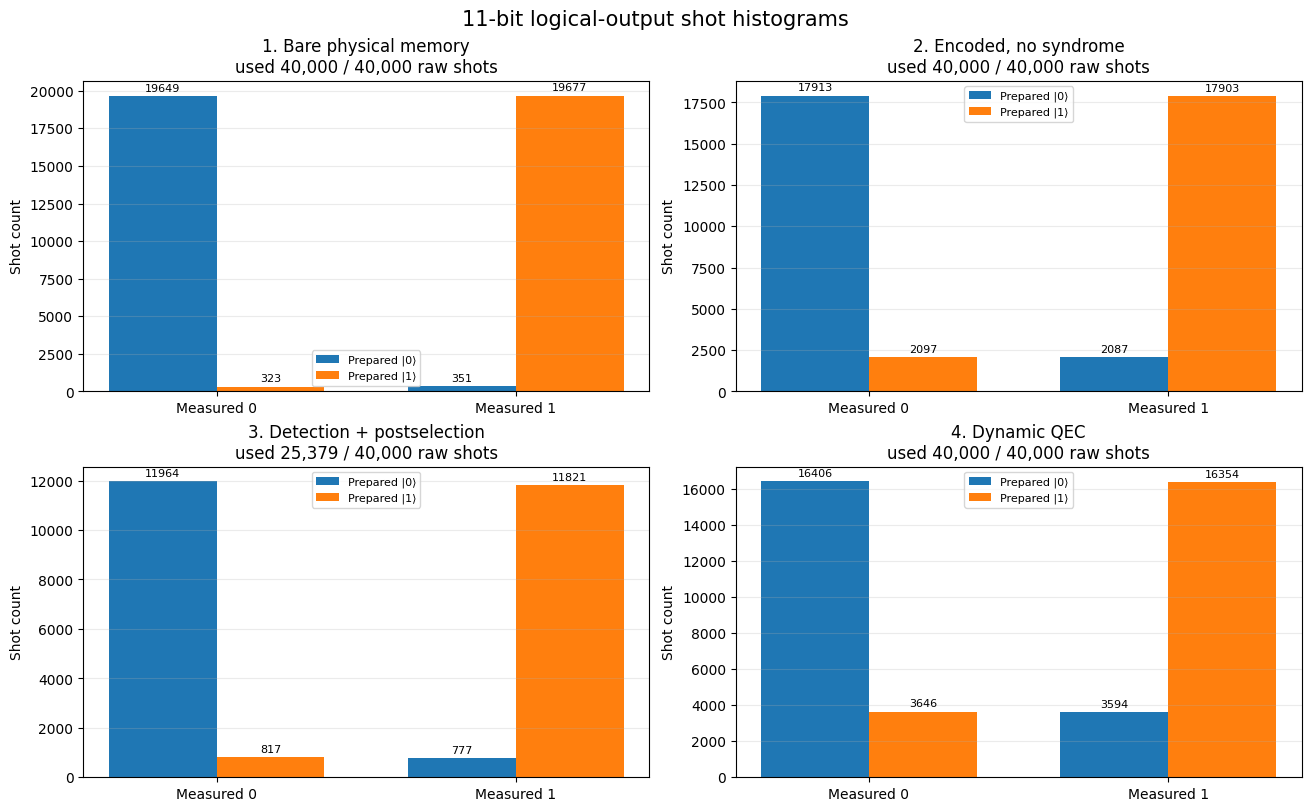

In [163]:
def collect_logical_histograms(raw_counts):
    histograms = {}
    used_shots = {}

    for experiment in EXPERIMENTS:
        histograms[experiment] = {0: {0: 0, 1: 0}, 1: {0: 0, 1: 0}}
        used_shots[experiment] = 0

        for prepared in (0, 1):
            for key, count in raw_counts[(experiment, prepared)].items():
                measured, syndrome = parse_count_key(key)
                if experiment == EXPERIMENTS[2] and syndrome != 0:
                    continue
                histograms[experiment][prepared][measured] += count
                used_shots[experiment] += count

    return histograms, used_shots


logical_histograms, used_shots = collect_logical_histograms(raw_counts)
x = np.arange(2)
width = 0.36
fig, axes = plt.subplots(2, 2, figsize=(13, 8), constrained_layout=True)

for ax, experiment in zip(axes.flat, EXPERIMENTS):
    input_zero = [logical_histograms[experiment][0][bit] for bit in (0, 1)]
    input_one = [logical_histograms[experiment][1][bit] for bit in (0, 1)]
    bars_zero = ax.bar(x - width / 2, input_zero, width, label='Prepared |0⟩')
    bars_one = ax.bar(x + width / 2, input_one, width, label='Prepared |1⟩')
    ax.bar_label(bars_zero, padding=2, fontsize=8)
    ax.bar_label(bars_one, padding=2, fontsize=8)
    ax.set_xticks(x, ['Measured 0', 'Measured 1'])
    ax.set_ylabel('Shot count')
    ax.set_title(
        f'{experiment}\nused {used_shots[experiment]:,} / {2 * SHOTS:,} raw shots'
    )
    ax.grid(axis='y', alpha=0.25)
    ax.legend(fontsize=8)

fig.suptitle(f'{CODE_DISTANCE}-bit logical-output shot histograms', fontsize=15)
plt.show()

11-bit repetition-code memory error rates:
  1. Bare physical memory: 1.6850% ± 0.0644%
  2. Encoded, no syndrome: 10.4600% ± 0.1530%
  3. Detection + postselection: 6.2808% ± 0.1523%
  4. Dynamic QEC: 18.1000% ± 0.1925%


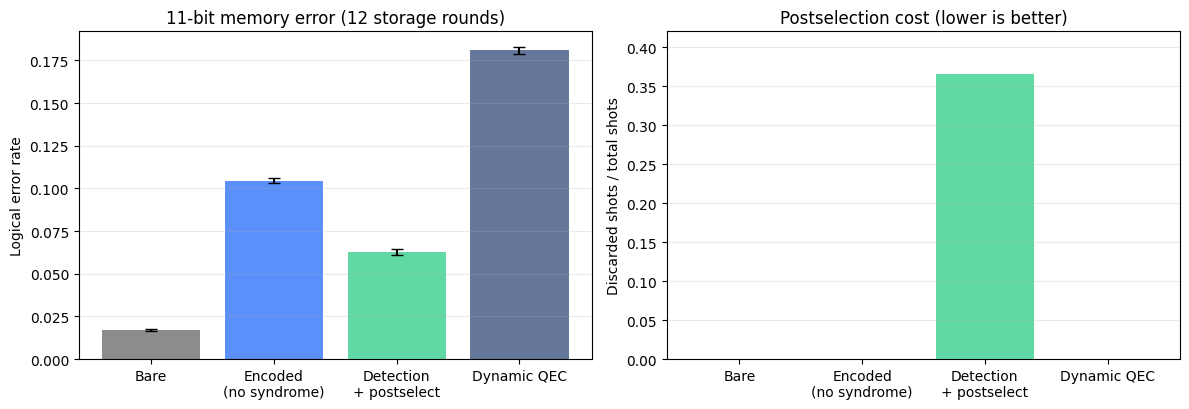

In [164]:
print(f'{CODE_DISTANCE}-bit repetition-code memory error rates:')
for experiment, row in comparison.iterrows():
    print(
        f"  {experiment}: {row['logical_error_rate']:.4%} "
        f"± {row['standard_error']:.4%}"
    )

labels = ['Bare', 'Encoded\n(no syndrome)', 'Detection\n+ postselect', 'Dynamic QEC']
x = np.arange(len(labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

axes[0].bar(
    x,
    comparison['logical_error_rate'],
    yerr=comparison['standard_error'],
    capsize=4,
    color=['#8c8c8c', '#5b8ff9', '#61d9a4', '#65789b'],
)
axes[0].set_xticks(x, labels)
axes[0].set_ylabel('Logical error rate')
axes[0].set_title(
    f'{CODE_DISTANCE}-bit memory error ({STORAGE_ROUNDS} storage rounds)'
)
axes[0].grid(axis='y', alpha=0.25)

axes[1].bar(
    x,
    comparison['discard_rate'],
    color=['#8c8c8c', '#5b8ff9', '#61d9a4', '#65789b'],
)
axes[1].set_xticks(x, labels)
axes[1].set_ylim(0, max(0.05, 1.15 * comparison['discard_rate'].max()))
axes[1].set_ylabel('Discarded shots / total shots')
axes[1].set_title('Postselection cost (lower is better)')
axes[1].grid(axis='y', alpha=0.25)

plt.tight_layout()
plt.show()

## Rotated surface-code memory

This section uses Stim's rotated surface-code memory circuits and PyMatching's minimum-weight perfect-matching (MWPM) decoder. It maps the repetition-code noise parameters as follows:

- `one_qubit_error`: depolarizing noise after each Hadamard gate
- `two_qubit_error`: two-qubit depolarizing noise after each CNOT
- `idle_error`: data-qubit depolarizing noise before each syndrome round
- `reset_error`: basis-appropriate reset flip probability
- `readout_error`: basis-appropriate measurement flip probability

`memory_z` is the closest comparison to the repetition-code computational-basis memory because both measure whether a logical bit was preserved. `memory_x` is also reported to show protection in the complementary basis.

> This is a structural benchmark, not a perfectly matched hardware-time comparison. The surface code performs repeated syndrome rounds and uses an offline MWPM decoder, while the dynamic repetition circuit performs one mid-memory correction round. A rotated distance-`d` surface code also uses `2d²-1` physical qubits, compared with `d+1` for the repetition circuit with one reused ancilla.

,logical_Z_error,logical_X_error,average_logical_error,average_standard_error,physical_qubits,rounds
distance,,,,,,
3,12.7200%,13.6200%,13.1700%,0.3382%,17,12
5,11.8200%,11.4800%,11.6500%,0.3208%,49,12
7,9.7600%,10.6200%,10.1900%,0.3025%,97,12
9,8.7800%,9.5800%,9.1800%,0.2887%,161,12


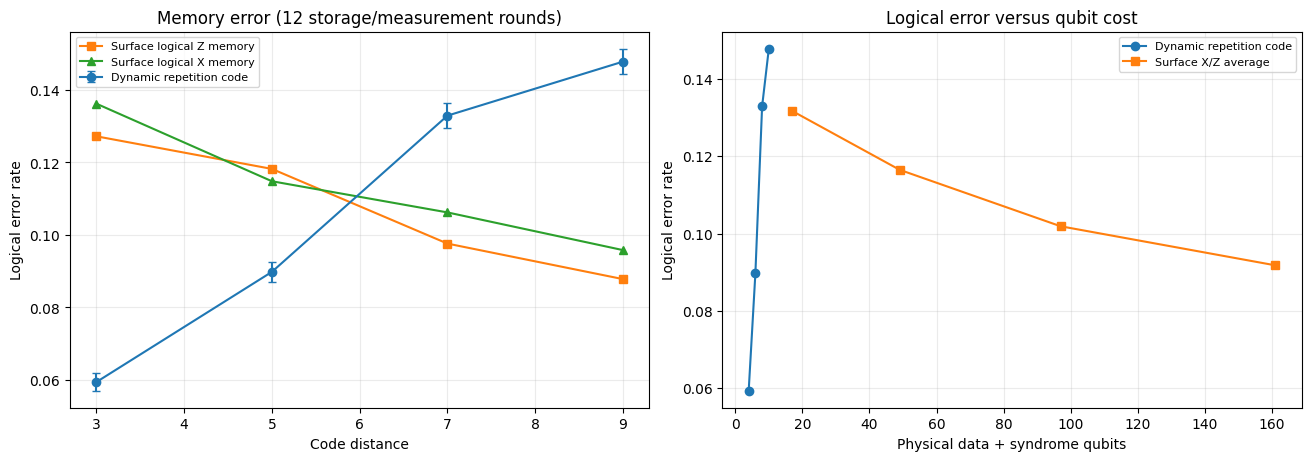

,distance,basis,logical_error_rate,standard_error,failures,shots,rounds,physical_qubits
0,3,Z,0.1272,0.004712,636,5000,12,17
1,3,X,0.1362,0.004851,681,5000,12,17
2,5,Z,0.1182,0.004566,591,5000,12,49
3,5,X,0.1148,0.004508,574,5000,12,49
4,7,Z,0.0976,0.004197,488,5000,12,97
5,7,X,0.1062,0.004357,531,5000,12,97
6,9,Z,0.0878,0.004002,439,5000,12,161
7,9,X,0.0958,0.004162,479,5000,12,161


In [165]:
import stim
import pymatching
from IPython.display import display

SURFACE_DISTANCES = (3, 5, 7, 9)
SURFACE_ROUNDS = STORAGE_ROUNDS
SURFACE_SHOTS = 5_000
SURFACE_NOISE_PARAMETERS = {
    'one_qubit_error': 0.001,
    'two_qubit_error': 0.01,
    'idle_error': 0.001,
    'reset_error': 0.01,
    'readout_error': 0.01,
}


def _add_stim_active_gate_noise(circuit, one_qubit_error, two_qubit_error):
    """Recursively add separate 1Q and 2Q depolarizing errors."""
    noisy = stim.Circuit()
    for instruction in circuit:
        if isinstance(instruction, stim.CircuitRepeatBlock):
            noisy_body = _add_stim_active_gate_noise(
                instruction.body_copy(),
                one_qubit_error,
                two_qubit_error,
            )
            noisy.append(stim.CircuitRepeatBlock(instruction.repeat_count, noisy_body))
            continue

        noisy.append(instruction)
        if instruction.name == 'H' and one_qubit_error:
            noisy.append(
                'DEPOLARIZE1', instruction.targets_copy(), one_qubit_error
            )
        elif instruction.name == 'CX' and two_qubit_error:
            noisy.append(
                'DEPOLARIZE2', instruction.targets_copy(), two_qubit_error
            )
    return noisy


def make_surface_code_circuit(
    distance,
    basis='z',
    rounds=SURFACE_ROUNDS,
    one_qubit_error=0.001,
    two_qubit_error=0.01,
    idle_error=0.001,
    reset_error=0.01,
    readout_error=0.01,
):
    """Build a noisy rotated surface-code memory circuit."""
    validate_code_distance(distance)
    if basis not in ('x', 'z'):
        raise ValueError("basis must be 'x' or 'z'")
    if not isinstance(rounds, int) or rounds < 1:
        raise ValueError('rounds must be a positive integer')

    circuit = stim.Circuit.generated(
        f'surface_code:rotated_memory_{basis}',
        distance=distance,
        rounds=rounds,
        after_clifford_depolarization=0,
        before_round_data_depolarization=idle_error,
        before_measure_flip_probability=readout_error,
        after_reset_flip_probability=reset_error,
    )
    return _add_stim_active_gate_noise(
        circuit,
        one_qubit_error=one_qubit_error,
        two_qubit_error=two_qubit_error,
    )


def run_surface_code_memory(
    distance,
    basis,
    rounds=SURFACE_ROUNDS,
    shots=SURFACE_SHOTS,
    seed=SEED,
    **noise_parameters,
):
    """Sample detector events and decode logical failures with MWPM."""
    circuit = make_surface_code_circuit(
        distance=distance,
        basis=basis,
        rounds=rounds,
        **noise_parameters,
    )
    detector_error_model = circuit.detector_error_model(decompose_errors=True)
    matching = pymatching.Matching.from_detector_error_model(detector_error_model)
    detection_events, observable_flips = circuit.compile_detector_sampler(
        seed=seed
    ).sample(shots=shots, separate_observables=True)
    predictions = matching.decode_batch(detection_events)
    failures = np.any(predictions != observable_flips, axis=1)
    failure_count = int(failures.sum())
    logical_error_rate = failure_count / shots
    standard_error = np.sqrt(
        logical_error_rate * (1 - logical_error_rate) / shots
    )
    return {
        'distance': distance,
        'basis': basis.upper(),
        'logical_error_rate': logical_error_rate,
        'standard_error': standard_error,
        'failures': failure_count,
        'shots': shots,
        'rounds': rounds,
        'physical_qubits': 2 * distance**2 - 1,
    }, circuit


def run_surface_code_sweep(
    distances=SURFACE_DISTANCES,
    rounds=SURFACE_ROUNDS,
    shots=SURFACE_SHOTS,
    seed=SEED,
    **noise_parameters,
):
    records = []
    circuits = {}
    for distance in distances:
        for basis_index, basis in enumerate(('z', 'x')):
            record, circuit = run_surface_code_memory(
                distance=distance,
                basis=basis,
                rounds=rounds,
                shots=shots,
                seed=seed + 2 * distance + basis_index,
                **noise_parameters,
            )
            records.append(record)
            circuits[(distance, basis)] = circuit
    return pd.DataFrame(records), circuits


def summarize_surface_results(surface_results):
    rows = []
    for distance, group in surface_results.groupby('distance', sort=True):
        total_failures = int(group['failures'].sum())
        total_shots = int(group['shots'].sum())
        average_error = total_failures / total_shots
        rows.append({
            'distance': distance,
            'logical_Z_error': group.loc[
                group['basis'] == 'Z', 'logical_error_rate'
            ].iloc[0],
            'logical_X_error': group.loc[
                group['basis'] == 'X', 'logical_error_rate'
            ].iloc[0],
            'average_logical_error': average_error,
            'average_standard_error': np.sqrt(
                average_error * (1 - average_error) / total_shots
            ),
            'physical_qubits': 2 * distance**2 - 1,
            'rounds': int(group['rounds'].iloc[0]),
        })
    return pd.DataFrame(rows).set_index('distance')


def run_repetition_dynamic_sweep(
    distances=SURFACE_DISTANCES,
    shots=SURFACE_SHOTS,
    storage_rounds=STORAGE_ROUNDS,
):
    rows = []
    for distance in distances:
        table, _, _ = run_comparison(
            n=distance,
            shots=shots,
            storage_rounds=storage_rounds,
        )
        result = table.loc[EXPERIMENTS[3]]
        rows.append({
            'distance': distance,
            'logical_error_rate': result['logical_error_rate'],
            'standard_error': result['standard_error'],
            'physical_qubits': distance + 1,
        })
    return pd.DataFrame(rows).set_index('distance')


surface_results, surface_circuits = run_surface_code_sweep(
    **SURFACE_NOISE_PARAMETERS
)
surface_summary = summarize_surface_results(surface_results)
repetition_dynamic_summary = run_repetition_dynamic_sweep()

display(surface_summary.style.format({
    'logical_Z_error': '{:.4%}',
    'logical_X_error': '{:.4%}',
    'average_logical_error': '{:.4%}',
    'average_standard_error': '{:.4%}',
    'physical_qubits': '{:,.0f}',
    'rounds': '{:,.0f}',
}))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), constrained_layout=True)
axes[0].errorbar(
    repetition_dynamic_summary.index,
    repetition_dynamic_summary['logical_error_rate'],
    yerr=repetition_dynamic_summary['standard_error'],
    fmt='o-', capsize=3, label='Dynamic repetition code',
)
axes[0].plot(
    surface_summary.index,
    surface_summary['logical_Z_error'],
    's-', label='Surface logical Z memory',
)
axes[0].plot(
    surface_summary.index,
    surface_summary['logical_X_error'],
    '^-', label='Surface logical X memory',
)
axes[0].set(
    xlabel='Code distance',
    ylabel='Logical error rate',
    title=f'Memory error ({STORAGE_ROUNDS} storage/measurement rounds)',
)
axes[0].grid(alpha=0.25)
axes[0].legend(fontsize=8)

axes[1].plot(
    repetition_dynamic_summary['physical_qubits'],
    repetition_dynamic_summary['logical_error_rate'],
    'o-', label='Dynamic repetition code',
)
axes[1].plot(
    surface_summary['physical_qubits'],
    surface_summary['average_logical_error'],
    's-', label='Surface X/Z average',
)
axes[1].set(
    xlabel='Physical data + syndrome qubits',
    ylabel='Logical error rate',
    title='Logical error versus qubit cost',
)
axes[1].grid(alpha=0.25)
axes[1].legend(fontsize=8)
plt.show()

surface_results